# TUTORIAL: Class EchoStateNetwork

Introduction to the `tools_ML.EchoStateNetwork` class. The echo state network class is based on Raca & Racca Magri (2021).

In this tutorial we will use an EchoStateNetwork to model the Lorenz 63 system. 


In [1]:
from tools_ML import EchoStateNetwork
# help(EchoStateNetwork)

# Create training data from the Lorenz 63 model

In [2]:
from utils import create_Lorenz63_dataset

# Create a Lorenz63 dataset with noise
dataset = create_Lorenz63_dataset(noise_level=0.02, num_lyap_times = 300)[0]

clean_data = dataset['clean_data']
noisy_data = dataset['noisy_data']
t = dataset['t']
N_lyap = dataset['N_lyap']

Loaded case


### Separate data into train, validation and test datasets and visualize

In [3]:
N_transient = 15 * N_lyap
N_val = 5 * N_lyap
N_train = 60 * N_lyap - N_val 
N_test = noisy_data.shape[0]-sum((N_train,N_val,N_transient))


train_val_data = noisy_data[N_transient:N_transient+N_train+2*N_val]

test_data = noisy_data[N_transient+N_train+N_val:N_transient+N_train+N_val+N_test]
test_data_clean = clean_data[N_transient+N_train+N_val:N_transient+N_train+N_val+N_test] # Truth to compare the tests


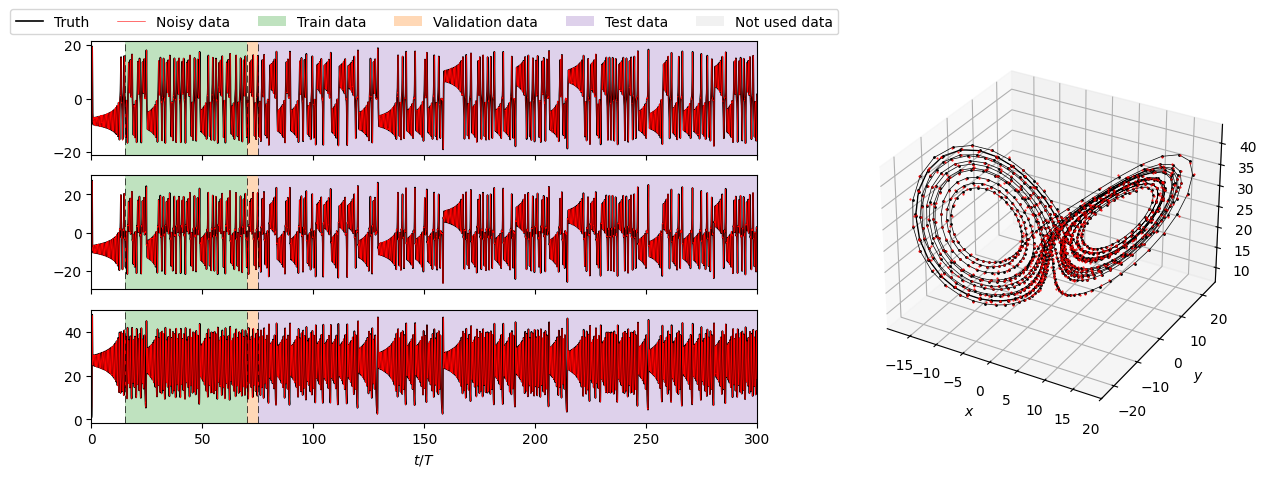

In [4]:
from plotting import plot_train_dataset

dt = t[1] - t[0]
t_lyap = N_lyap * dt

split_times = [tt / N_lyap for tt in [N_transient, N_train, N_val, N_test]]

plot_train_dataset(clean_data, noisy_data, t/t_lyap, *split_times)

# Initialize the ESN
NB: Different initializations result in different Wout.

In [5]:
import numpy as np

ESN_params = dict(N_wash=10,  # Number of washout steps i.e., open-loop initialization
                  N_units=50,  # Number of neurons 
                  upsample=2, # We want the ESN to predict t + upsample * dt 
                  t_train=N_train * dt,  # Training time
                  t_val=N_val * dt, # Validation time
                  t_test=2*N_val * dt, # Validation time
                  # Training-specific input_parameters
                  N_func_evals=30,
                  N_grid=5,
                  noise=1e-2,
                  Win_type='sparse',
                  N_folds=8,
                  N_split=5,
                  # Hyperparameter optimization ranges
                  rho_range=(.2, .95),
                  sigma_in_range=(-2, 2),
                  tikh_range=[1E-9, 1E-10],
                #   random_initialization=True
                  )


# Initialize ESN class
ESN_init = EchoStateNetwork(y=np.zeros((3,1)), 
                       dt=dt, 
                       **ESN_params)


# Train the ESN
The result of the ESN training is the output matrix. We can train the network to input the full state or partial observations.

## a) Full observability


seed 0 	 Optimal hyperparameters: [0.32026346833681063, 0.8970367287863312], 1e-09, MSE: -0.9002918268403197

 ----------------- HYPERPARAMETER SEARCH ------------------
 5x5 grid and 5 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 2.000e-01	 1.000e-02	 1.000e-09	 -0.8666
2	 2.000e-01	 1.000e-01	 1.000e-09	 -0.1926
3	 2.000e-01	 1.000e+00	 1.000e-09	 -0.4936
4	 2.000e-01	 1.000e+01	 1.000e-09	 -0.8530
5	 2.000e-01	 1.000e+02	 1.000e-09	 -0.7912
6	 3.875e-01	 1.000e-02	 1.000e-09	 -0.3719
7	 3.875e-01	 1.000e-01	 1.000e-09	 3.9080
8	 3.875e-01	 1.000e+00	 1.000e-09	 -0.6590
9	 3.875e-01	 1.000e+01	 1.000e-09	 -0.8280
10	 3.875e-01	 1.000e+02	 1.000e-09	 -0.7776
11	 5.750e-01	 1.000e-02	 1.000e-09	 -0.4508
12	 5.750e-01	 1.000e-01	 1.000e-09	 3.9621
13	 5.750e-01	 1.000e+00	 1.000e-09	 -0.4997
14	 5.750e-01	 1.000e+01	 1.000e-09	 -0.7571
15	 5.750e-01	 1.000e+02	 1.000e-09	 -0.7836
16	 7.625e-01	 1.000e-02	 1.000e-09	 -0.4299
17	 7.625e-01	 1.000e-01	 1.000e-09	 3

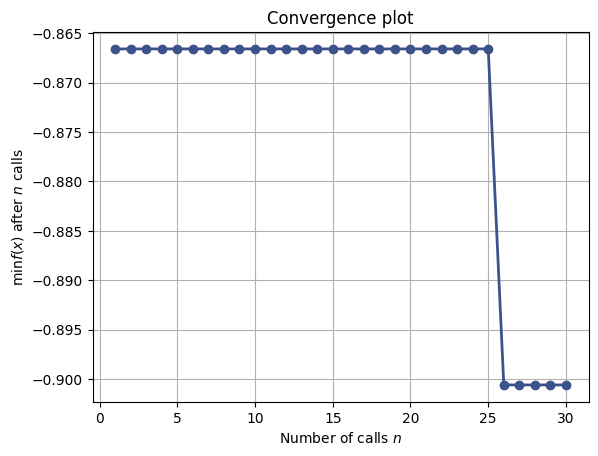

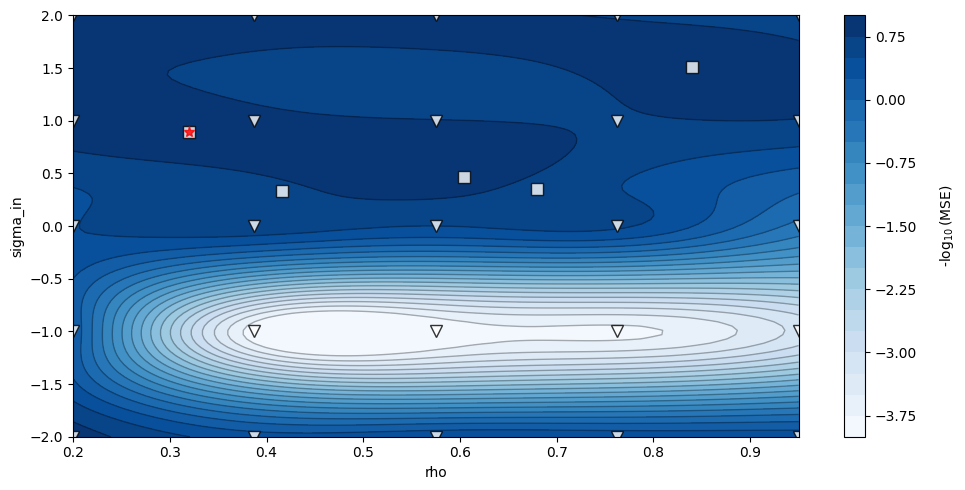

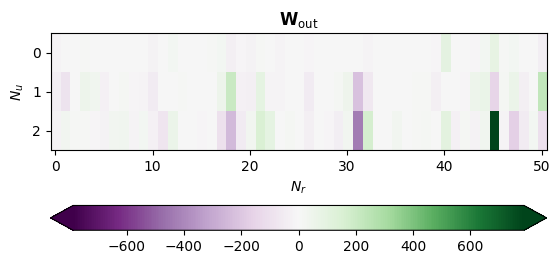

In [6]:
seeds= [0, 252]
for seed in seeds:
    ESN = ESN_init.copy()
    ESN.seed_W = seed
    ESN.train(train_val_data, 
              add_noise=True, 
              plot_training=seed==seeds[-1]
             )

### Test the long-term prediction

## b) Partial observability


 ----------------- HYPERPARAMETER SEARCH ------------------
 5x5 grid and 5 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 4.000e-01	 1.000e-02	 1.000e-09	 -0.8419
2	 4.000e-01	 1.000e-01	 1.000e-09	 0.1575
3	 4.000e-01	 1.000e+00	 1.000e-09	 -0.7227
4	 4.000e-01	 1.000e+01	 1.000e-09	 -0.6768
5	 4.000e-01	 1.000e+02	 1.000e-09	 -0.6363
6	 5.375e-01	 1.000e-02	 1.000e-09	 -0.5034
7	 5.375e-01	 1.000e-01	 1.000e-09	 0.1106
8	 5.375e-01	 1.000e+00	 1.000e-09	 -0.6663
9	 5.375e-01	 1.000e+01	 1.000e-09	 -0.6884
10	 5.375e-01	 1.000e+02	 1.000e-09	 -0.6330
11	 6.750e-01	 1.000e-02	 1.000e-09	 -0.5222
12	 6.750e-01	 1.000e-01	 1.000e-09	 2.1020
13	 6.750e-01	 1.000e+00	 1.000e-09	 -0.4694
14	 6.750e-01	 1.000e+01	 1.000e-09	 -0.7026
15	 6.750e-01	 1.000e+02	 1.000e-09	 -0.6327
16	 8.125e-01	 1.000e-02	 1.000e-09	 -0.5114
17	 8.125e-01	 1.000e-01	 1.000e-09	 3.2251
18	 8.125e-01	 1.000e+00	 1.000e-09	 -0.5255
19	 8.125e-01	 1.000e+01	 1.000e-09	 -0.6762
20	 8.125e-01	

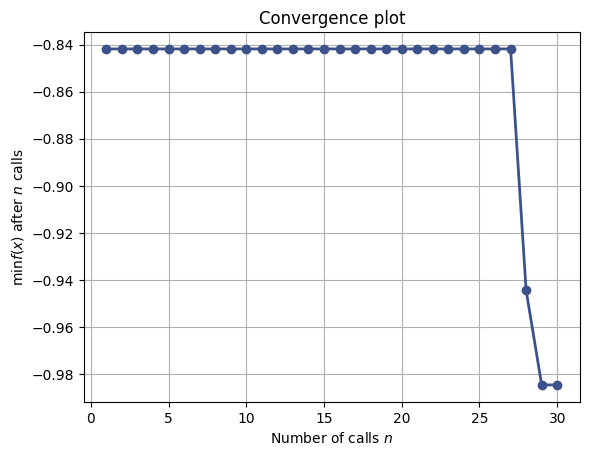

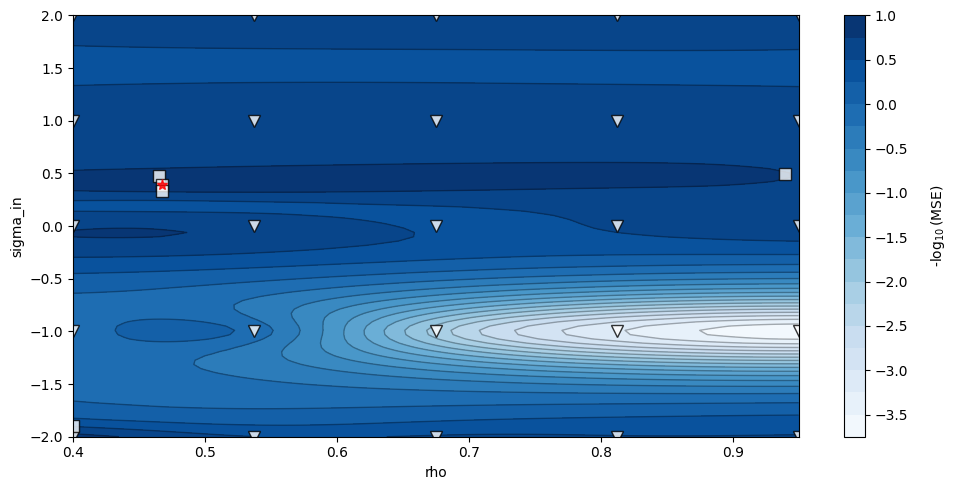

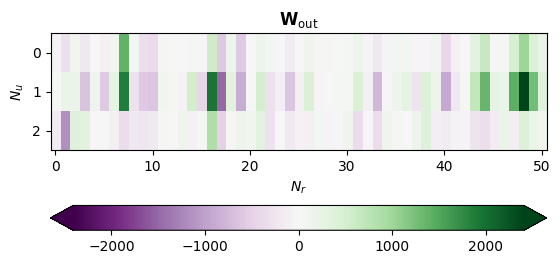

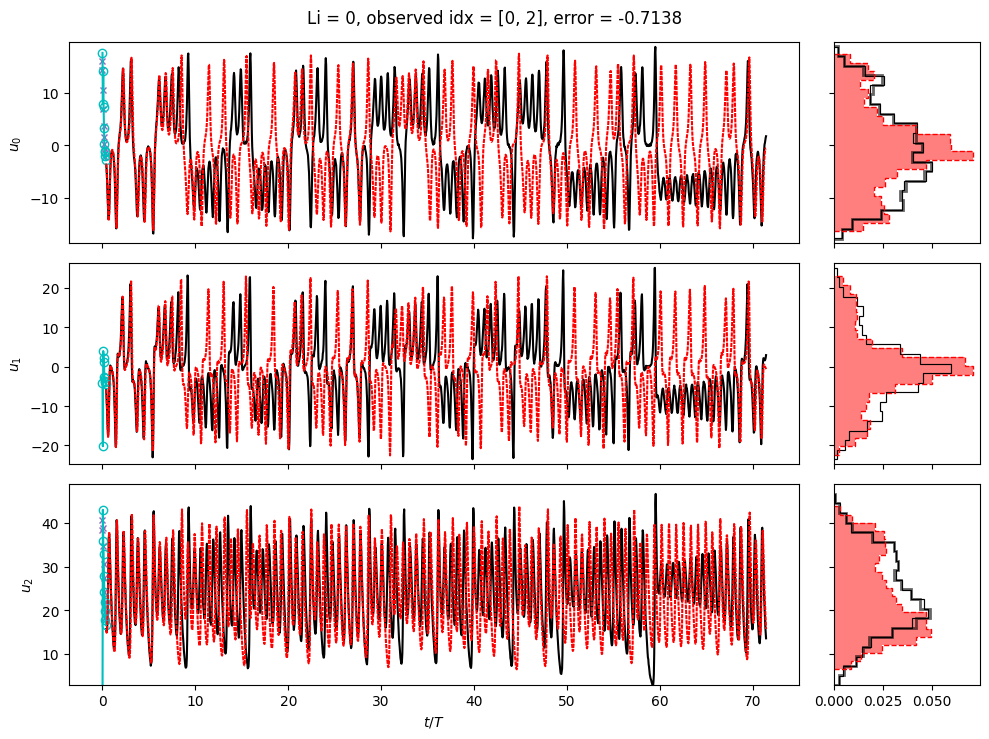

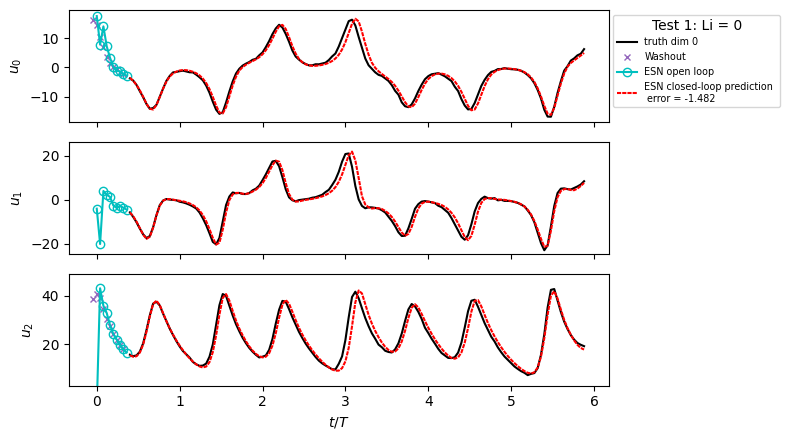

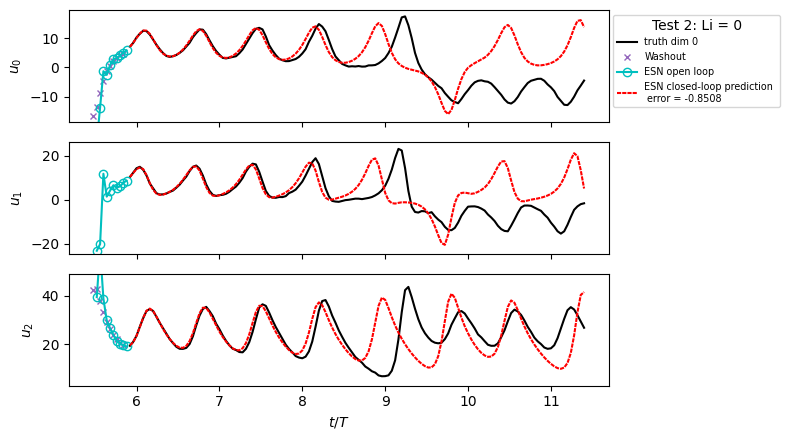

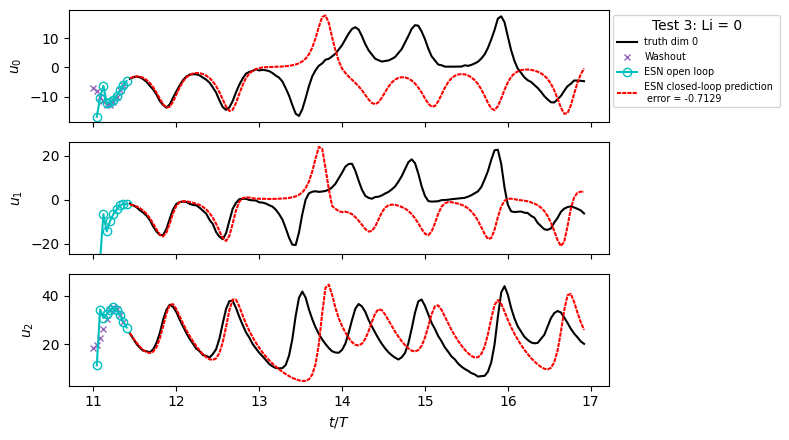

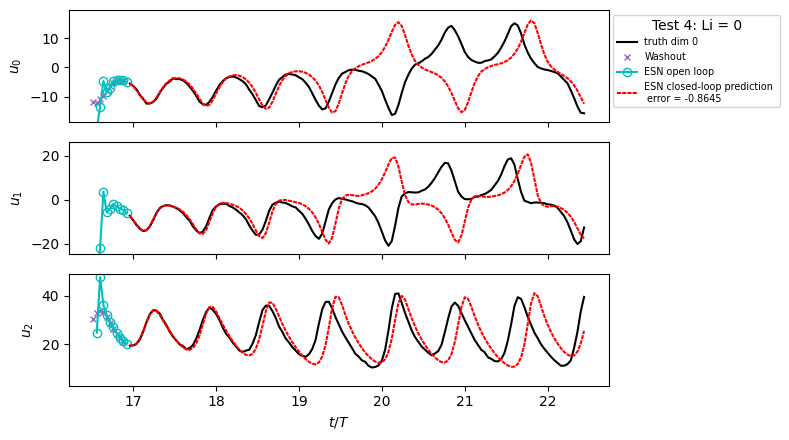

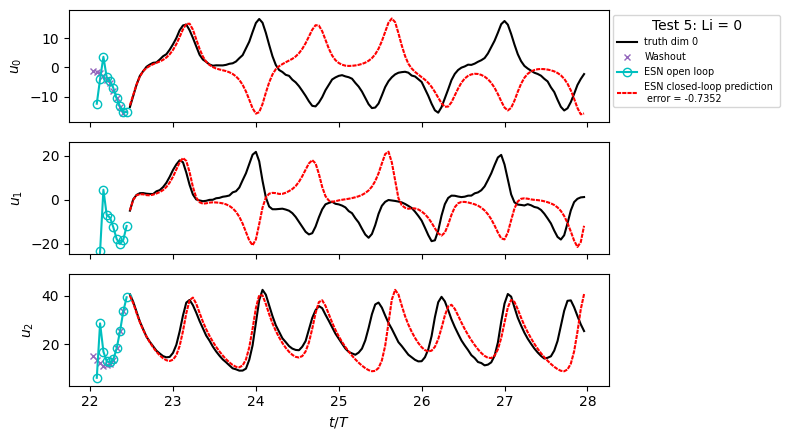

In [7]:
N_transient = 15 * N_lyap
N_val = 5 * N_lyap
N_train = 120 * N_lyap - N_val 
N_test = noisy_data.shape[0]-sum((N_train,N_val,N_transient))

train_val_data = noisy_data[N_transient:N_transient+N_train+2*N_val]


# Define Echo state network input_parameters

ESN_partial = ESN_init.copy()
ESN_partial.N_folds = 12
ESN_partial.rho_range = (0.4, 0.95)

# Set the observed dimensions
ESN_partial.observed_idx = [0, 2]


ESN_partial.train(train_val_data, 
          add_noise=True, 
          plot_training=True,
         )

If prediction is much worse, try increasing the length of the timeseries or number of folds.